#### Import Libraries

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import os

#### Load Clean Data

In [51]:
data_path = r"C:\Users\Hassa\OneDrive - Loughborough University\current\Algorithmic Trading for Beginners\FTSA\TSACapstoneTemplate\TSACapstoneTemplate\data_modules"

df_aud = pd.read_pickle(os.path.join(data_path, "fx_pair_1_4h_clean.pkl"))
df_eur = pd.read_pickle(os.path.join(data_path, "fx_pair_2_4h_clean.pkl"))

print(f"AUD/USD shape: {df_aud.shape}")
print(f"EUR/USD shape: {df_eur.shape}")

AUD/USD shape: (4861, 5)
EUR/USD shape: (4861, 5)


In [52]:
def sanity_check_02(df):
    # Adding check for missing data
    # Groupby data points available on each day
    temp = df.groupby(df.index.date).count()
    # Since the data is resampled to 4 hour frequency, there are 6 data points in one day
    temp = temp[temp['close']!=6]
    # View dates where the data is missing. Since we are dealing with hourly data, there will be 24 data points in 24 hours.
    print("Removing {} data points".format(len(temp)))
    '''
    To maintain consistent data, we consider the dates for which full data is available.
    A better option would be to use a reliable data source.
    '''
    to_delete = list(pd.to_datetime(temp.index))
    return df[~(df.index.isin(to_delete))]

df_aud = sanity_check_02(df_aud)
df_eur = sanity_check_02(df_eur)

Removing 169 data points
Removing 169 data points


#### Visual Inspection

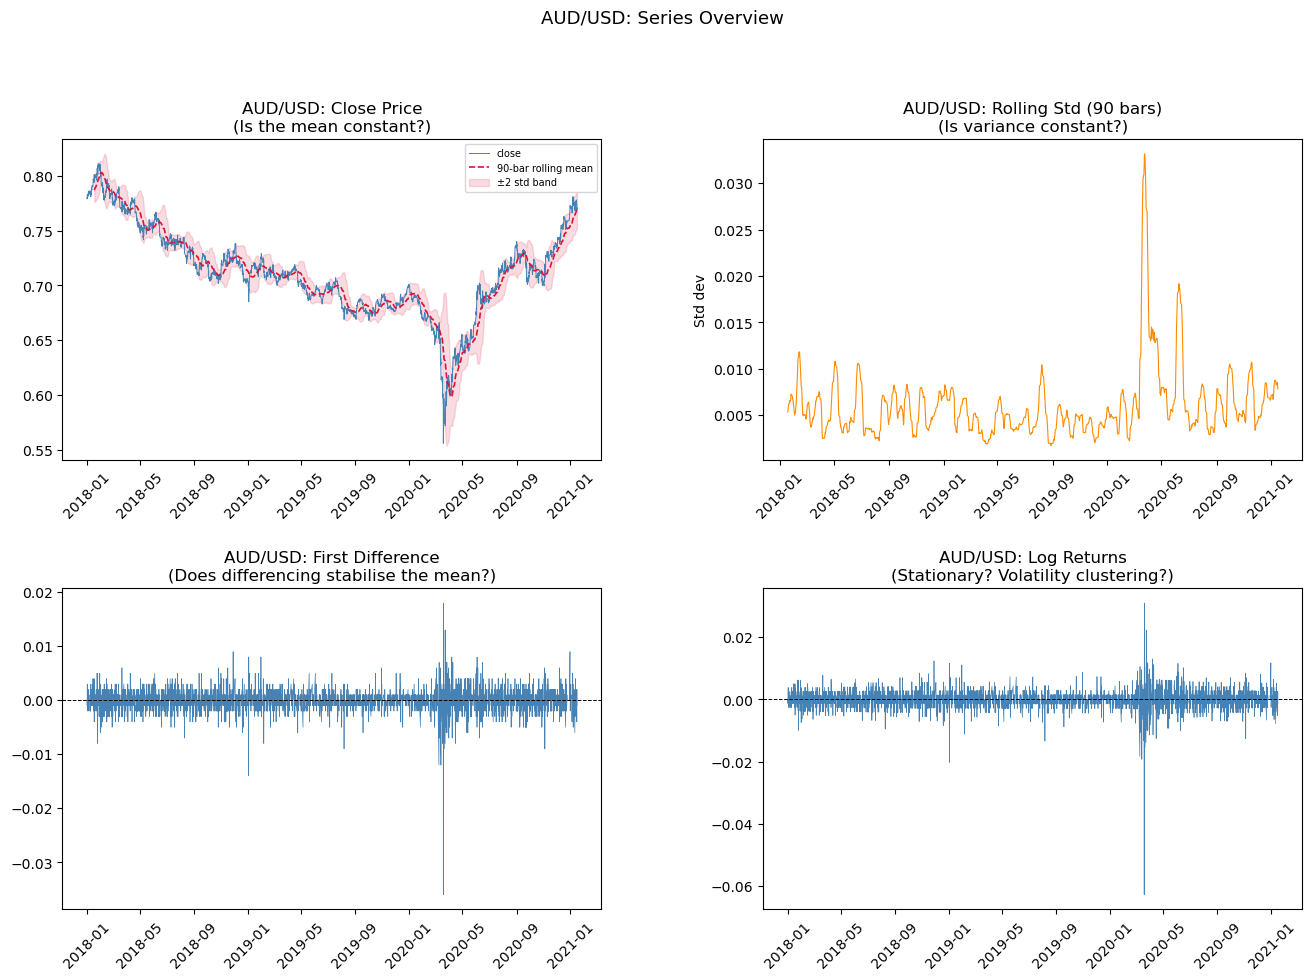

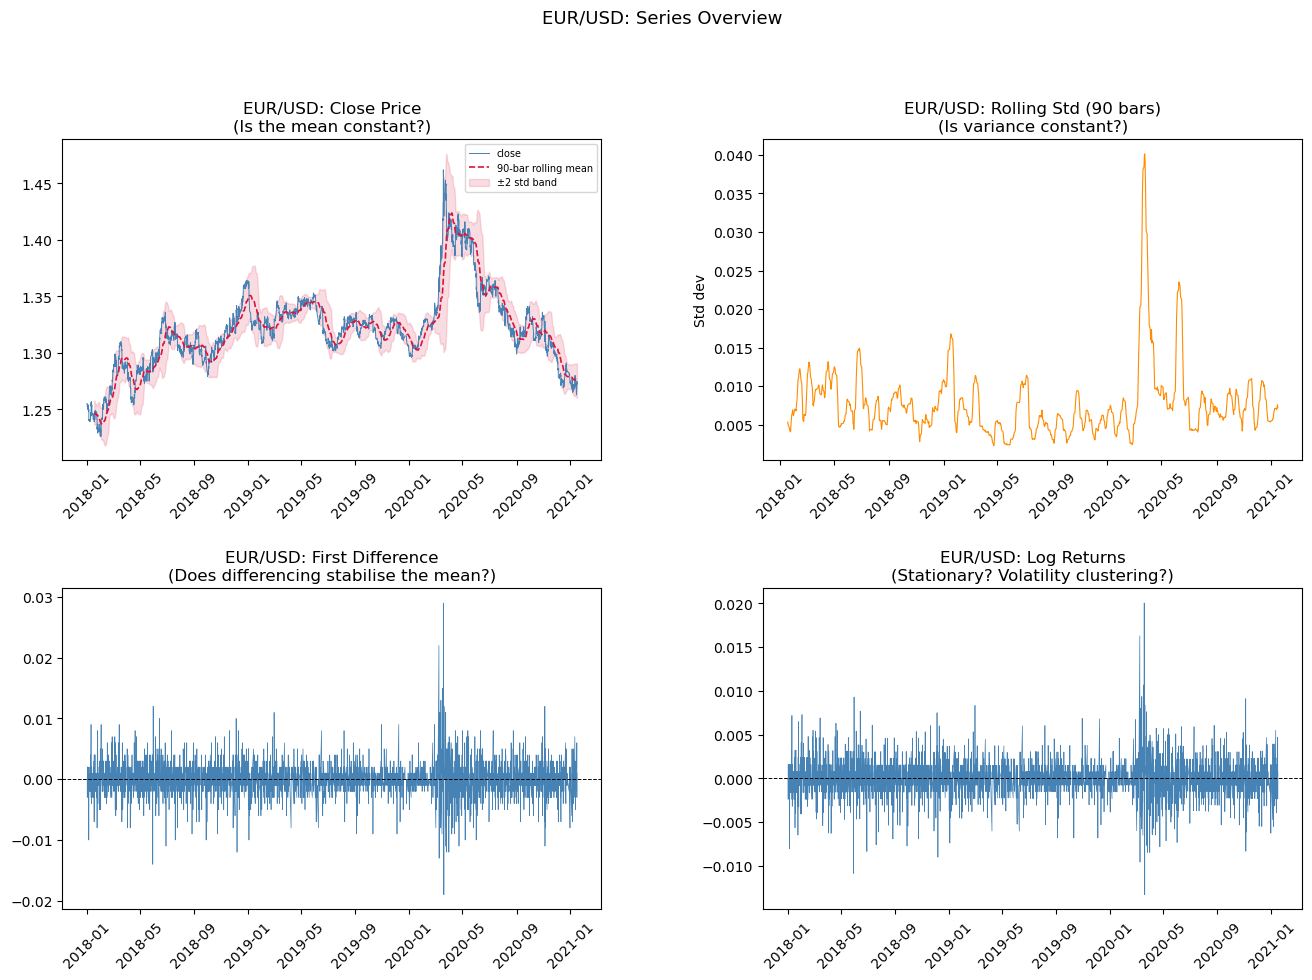

In [53]:
def plot_series_overview(df, pair_name):
    """
    Four-panel overview: price, log-returns, first difference, and
    rolling statistics. Looking at all four together gives an intuition
    for stationarity before running any formal test.
    """
    close       = df["close"]
    log_returns = np.log(close).diff().dropna()
    first_diff  = close.diff().dropna()
    roll_mean   = close.rolling(window=90).mean()   # ~15 trading days
    roll_std    = close.rolling(window=90).std()

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

    # Panel 1: raw close with rolling mean
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(close.index, close, color="steelblue", linewidth=0.7, label="close")
    ax1.plot(roll_mean.index, roll_mean, color="crimson", linewidth=1.2,
             linestyle="--", label="90-bar rolling mean")
    ax1.fill_between(roll_std.index,
                     roll_mean - 2*roll_std,
                     roll_mean + 2*roll_std,
                     alpha=0.15, color="crimson", label="±2 std band")
    ax1.set_title(f"{pair_name}: Close Price\n(Is the mean constant?)")
    ax1.legend(fontsize=7)
    ax1.tick_params(axis='x', labelrotation=45)
    
    # Panel 2: rolling std alone (constant variance = stationary signal)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(roll_std.index, roll_std, color="darkorange", linewidth=0.8)
    ax2.set_title(f"{pair_name}: Rolling Std (90 bars)\n(Is variance constant?)")
    ax2.set_ylabel("Std dev")
    ax2.tick_params(axis='x', labelrotation=45)
    
    # Panel 3: first difference
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(first_diff.index, first_diff, color="steelblue", linewidth=0.5)
    ax3.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax3.set_title(f"{pair_name}: First Difference\n(Does differencing stabilise the mean?)")
    ax3.tick_params(axis='x', labelrotation=45)
    
    # Panel 4: log returns
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(log_returns.index, log_returns, color="steelblue", linewidth=0.5)
    ax4.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax4.set_title(f"{pair_name}: Log Returns\n(Stationary? Volatility clustering?)")
    ax4.tick_params(axis='x', labelrotation=45)
    
    plt.suptitle(f"{pair_name}: Series Overview", fontsize=13, y=1.01)
    plt.show()

plot_series_overview(df_aud, "AUD/USD")
plot_series_overview(df_eur, "EUR/USD")

####  Formal Stationarity Tests: ADF and KPSS

In [54]:
def run_stationarity_tests(series, series_name="Series", alpha=0.05):
    """
    Run ADF and KPSS tests and reconcile their conclusions.

    ADF  null hypothesis: unit root IS present (non-stationary)
         Reject null (p < alpha) --> stationary
    KPSS null hypothesis: series IS stationary
         Reject null (p < alpha) --> non-stationary

    The two tests are complementary. When they disagree, the series
    is likely trend-stationary rather than difference-stationary.
    """
    print(f"  STATIONARITY TESTS: {series_name}")
    print(f"{'-'*55}")

    # ADF test
    adf_result = adfuller(series.dropna(), autolag="AIC")
    adf_stat, adf_p = adf_result[0], adf_result[1]
    adf_conclusion = "STATIONARY" if adf_p < alpha else "NON-STATIONARY"

    print(f"\n  Augmented Dickey-Fuller Test")
    print(f"  {'ADF statistic':<25}: {adf_stat:.4f}")
    print(f"  {'p-value':<25}: {adf_p:.6f}")
    print(f"  {'Critical value (1%)':<25}: {adf_result[4]['1%']:.4f}")
    print(f"  {'Critical value (5%)':<25}: {adf_result[4]['5%']:.4f}")
    print(f"  {'Critical value (10%)':<25}: {adf_result[4]['10%']:.4f}")
    print(f"  {'Conclusion':<25}: {adf_conclusion}")

    # KPSS test
    try:
        kpss_result = kpss(series.dropna(), regression="c", nlags="auto")
        kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
        kpss_conclusion = "NON-STATIONARY" if kpss_p < alpha else "STATIONARY"

        print(f"\n  KPSS Test (level stationarity)")
        print(f"  {'KPSS statistic':<25}: {kpss_stat:.4f}")
        print(f"  {'p-value':<25}: {kpss_p:.6f}")
        print(f"  {'Critical value (5%)':<25}: {kpss_result[3]['5%']:.4f}")
        print(f"  {'Conclusion':<25}: {kpss_conclusion}")
    except Exception as e:
        kpss_conclusion = "UNKNOWN"
        print(f"\n  KPSS test failed: {e}")

    # Reconcile
    print(f"\n  RECONCILIATION")
    if adf_conclusion == "STATIONARY" and kpss_conclusion == "STATIONARY":
        verdict = "STATIONARY -- use ARMA"
    elif adf_conclusion == "NON-STATIONARY" and kpss_conclusion == "NON-STATIONARY":
        verdict = "NON-STATIONARY -- difference and retest, use ARIMA"
    elif adf_conclusion == "STATIONARY" and kpss_conclusion == "NON-STATIONARY":
        verdict = "TREND-STATIONARY -- consider detrending or first difference"
    else:
        verdict = "DIFFERENCE-STATIONARY -- unit root likely, use ARIMA"
    print(f"  {verdict}")

    return {"adf_stat": adf_stat, "adf_p": adf_p, "kpss_stat": kpss_stat,
            "kpss_p": kpss_p, "verdict": verdict}


# Test raw close prices
print("\nRAW CLOSE PRICE")
result_aud_raw = run_stationarity_tests(df_aud["close"], "AUD/USD close")
result_eur_raw = run_stationarity_tests(df_eur["close"], "EUR/USD close")

# Test first differences
print("\nFIRST DIFFERENCE")
result_aud_d1 = run_stationarity_tests(df_aud["close"].diff().dropna(), "AUD/USD d(close)")
result_eur_d1 = run_stationarity_tests(df_eur["close"].diff().dropna(), "EUR/USD d(close)")


RAW CLOSE PRICE
  STATIONARITY TESTS: AUD/USD close
-------------------------------------------------------

  Augmented Dickey-Fuller Test
  ADF statistic            : -1.7689
  p-value                  : 0.396023
  Critical value (1%)      : -3.4318
  Critical value (5%)      : -2.8622
  Critical value (10%)     : -2.5671
  Conclusion               : NON-STATIONARY

  KPSS Test (level stationarity)
  KPSS statistic           : 5.0031
  p-value                  : 0.010000
  Critical value (5%)      : 0.4630
  Conclusion               : NON-STATIONARY

  RECONCILIATION
  NON-STATIONARY -- difference and retest, use ARIMA
  STATIONARITY TESTS: EUR/USD close
-------------------------------------------------------

  Augmented Dickey-Fuller Test
  ADF statistic            : -2.4036
  p-value                  : 0.140711
  Critical value (1%)      : -3.4317
  Critical value (5%)      : -2.8622
  Critical value (10%)     : -2.5671
  Conclusion               : NON-STATIONARY

  KPSS Test (le

#### Determine Integration Order d

In [55]:
def find_integration_order(series, pair_name, max_d=2, alpha=0.05):
    """
    Iteratively difference the series until the ADF test rejects the
    null hypothesis of a unit root. The number of differences required
    is the integration order d for ARIMA(p, d, q).
    """
    print(f"\n{pair_name}: searching for integration order d")
    print(f"{'d':<5} {'ADF p-value':<15} {'Conclusion'}")
    print("-" * 40)

    current = series.copy().dropna()
    for d in range(max_d + 1):
        adf_p = adfuller(current, autolag="AIC")[1]
        conclusion = "STATIONARY -- stop here" if adf_p < alpha else "non-stationary"
        print(f"{d:<5} {adf_p:<15.6f} {conclusion}")
        if adf_p < alpha:
            print(f"\n  --> Integration order d = {d}")
            return d
        current = current.diff().dropna()

    print(f"\n  --> Could not achieve stationarity within d={max_d}. Check for structural breaks.")
    return max_d

d_aud = find_integration_order(df_aud["close"], "AUD/USD")
d_eur = find_integration_order(df_eur["close"], "EUR/USD")


AUD/USD: searching for integration order d
d     ADF p-value     Conclusion
----------------------------------------
0     0.396023        non-stationary
1     0.000000        STATIONARY -- stop here

  --> Integration order d = 1

EUR/USD: searching for integration order d
d     ADF p-value     Conclusion
----------------------------------------
0     0.140711        non-stationary
1     0.000000        STATIONARY -- stop here

  --> Integration order d = 1


#### ACF and PACF Analysis

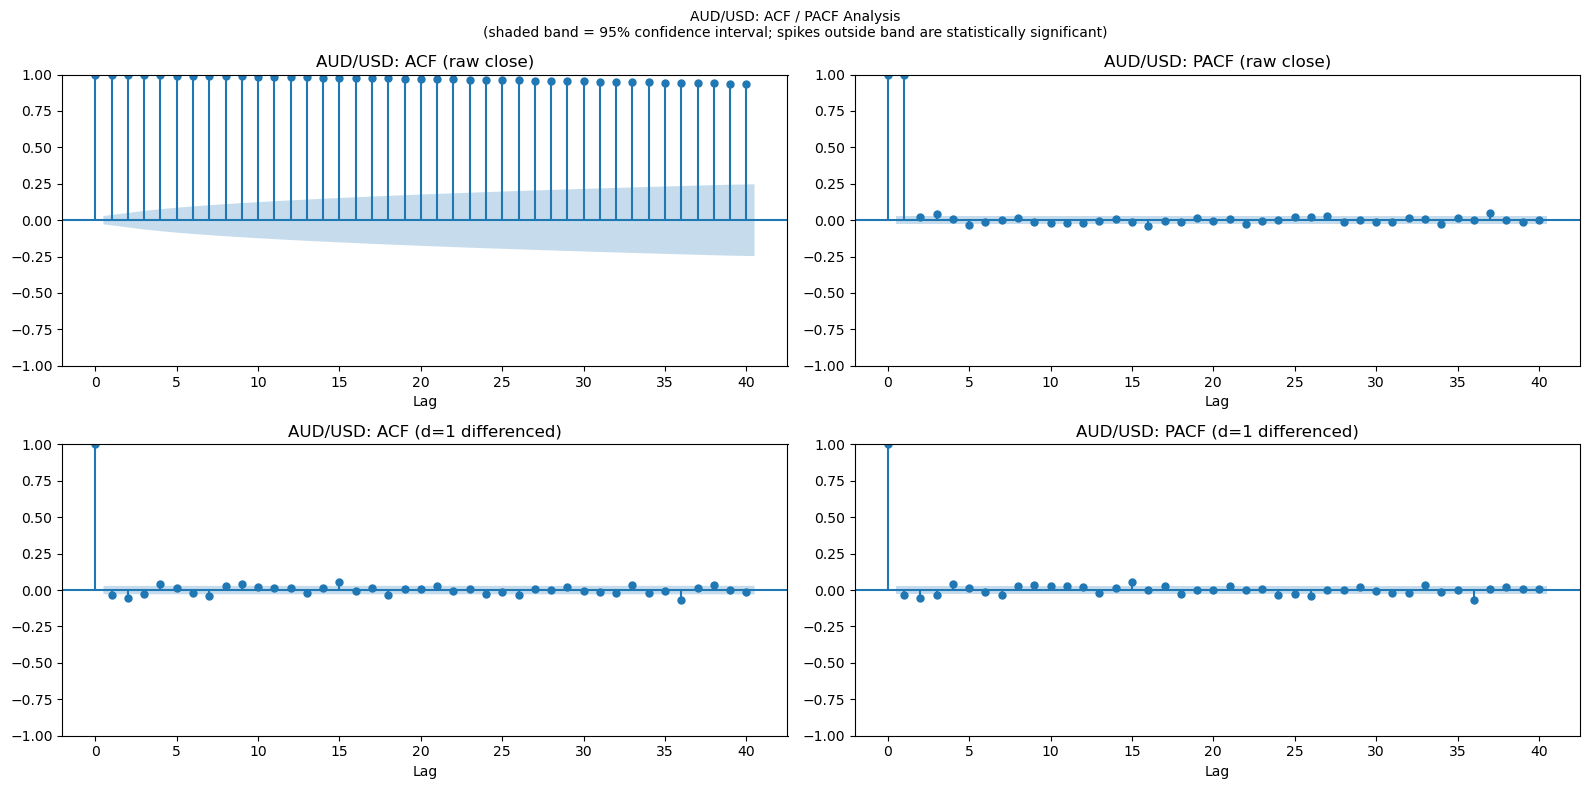

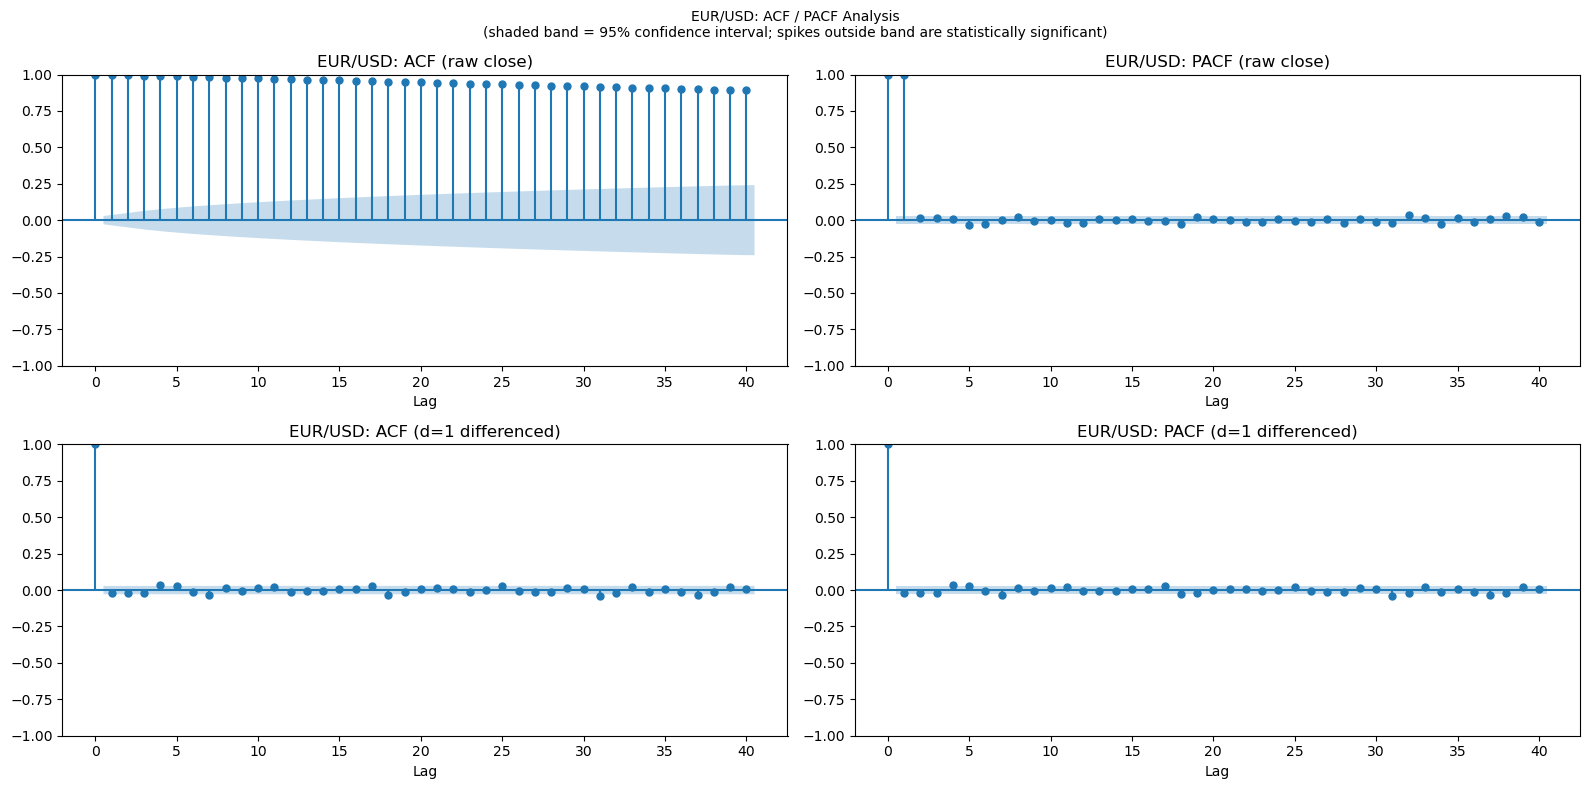

In [56]:
def plot_acf_pacf(series, pair_name, d=1, lags=40):
    """
    Plot ACF and PACF for both the raw series and the differenced series.

    How to read these plots for model order selection:
    ---------------------------------------------------------
    AR(p) signature : PACF cuts off after lag p, ACF tails off
    MA(q) signature : ACF cuts off after lag q, PACF tails off
    ARMA(p,q)       : Both ACF and PACF tail off gradually

    The d-times differenced series is what we read for p and q.
    """
    differenced = series.copy()
    for _ in range(d):
        differenced = differenced.diff().dropna()

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    # Raw series
    plot_acf(series.dropna(),  lags=lags, ax=axes[0][0], title=f"{pair_name}: ACF (raw close)",  alpha=0.05)
    plot_pacf(series.dropna(), lags=lags, ax=axes[0][1], title=f"{pair_name}: PACF (raw close)", alpha=0.05, method="ywm")

    # Differenced series
    plot_acf(differenced,  lags=lags, ax=axes[1][0], title=f"{pair_name}: ACF (d={d} differenced)",  alpha=0.05)
    plot_pacf(differenced, lags=lags, ax=axes[1][1], title=f"{pair_name}: PACF (d={d} differenced)", alpha=0.05, method="ywm")

    for ax in axes.flatten():
        ax.set_xlabel("Lag")

    plt.suptitle(f"{pair_name}: ACF / PACF Analysis\n"
                 f"(shaded band = 95% confidence interval; "
                 f"spikes outside band are statistically significant)",
                 fontsize=10)
    plt.tight_layout()
    plt.show()

plot_acf_pacf(df_aud["close"], "AUD/USD", d=d_aud)
plot_acf_pacf(df_eur["close"], "EUR/USD", d=d_eur)

#### Check for Seasonality

In [57]:
def check_seasonality(series, pair_name, d=1, seasonal_lags=[6, 12, 24, 42]):
    """
    Is there a seasonal component worth modelling with SARIMA?

    On 4-hour bars:
        6  bars = 1 trading day
        30 bars = 1 trading week (5 days x 6 bars)
        42 bars ~ 1 week including typical open/close gaps

    We look for statistically significant ACF spikes at these lags
    in the differenced series. If we find them, SARIMA is worth fitting.
    """
    differenced = series.copy()
    for _ in range(d):
        differenced = differenced.diff().dropna()

    acf_vals, confint = acf(differenced.dropna(), nlags=max(seasonal_lags) + 5,
                            alpha=0.05, fft=True)

    print(f"\n{pair_name}: ACF at seasonal candidate lags (after {d} difference(s))")
    print(f"{'Lag':<8} {'Bars meaning':<25} {'ACF':<10} {'95% CI lower':<15} {'95% CI upper':<15} {'Significant?'}")
    print("-" * 85)

    lag_meanings = {6: "~1 trading day", 12: "~2 trading days",
                    24: "~4 trading days", 42: "~1 trading week"}
    seasonal_found = False

    for lag in seasonal_lags:
        if lag < len(acf_vals):
            val = acf_vals[lag]
            lo  = confint[lag][0] - val
            hi  = confint[lag][1] - val
            sig = abs(val) > abs(hi)
            if sig:
                seasonal_found = True
            meaning = lag_meanings.get(lag, "")
            print(f"{lag:<8} {meaning:<25} {val:<10.4f} {lo:<15.4f} {hi:<15.4f} {'YES ***' if sig else 'no'}")

    print(f"\n  Seasonality detected: {seasonal_found}")
    print(f"  Model recommendation: {'SARIMA' if seasonal_found else 'ARIMA (no seasonal component needed)'}")
    return seasonal_found

seasonal_aud = check_seasonality(df_aud["close"], "AUD/USD", d=d_aud)
seasonal_eur = check_seasonality(df_eur["close"], "EUR/USD", d=d_eur)


AUD/USD: ACF at seasonal candidate lags (after 1 difference(s))
Lag      Bars meaning              ACF        95% CI lower    95% CI upper    Significant?
-------------------------------------------------------------------------------------
6        ~1 trading day            -0.0198    -0.0288         0.0288          no
12       ~2 trading days           0.0148     -0.0290         0.0290          no
24       ~4 trading days           -0.0278    -0.0291         0.0291          no
42       ~1 trading week           0.0011     -0.0294         0.0294          no

  Seasonality detected: False
  Model recommendation: ARIMA (no seasonal component needed)

EUR/USD: ACF at seasonal candidate lags (after 1 difference(s))
Lag      Bars meaning              ACF        95% CI lower    95% CI upper    Significant?
-------------------------------------------------------------------------------------
6        ~1 trading day            -0.0098    -0.0287         0.0287          no
12       ~2 trading

#### Step 1: Remove Trend, Visualise What Remains

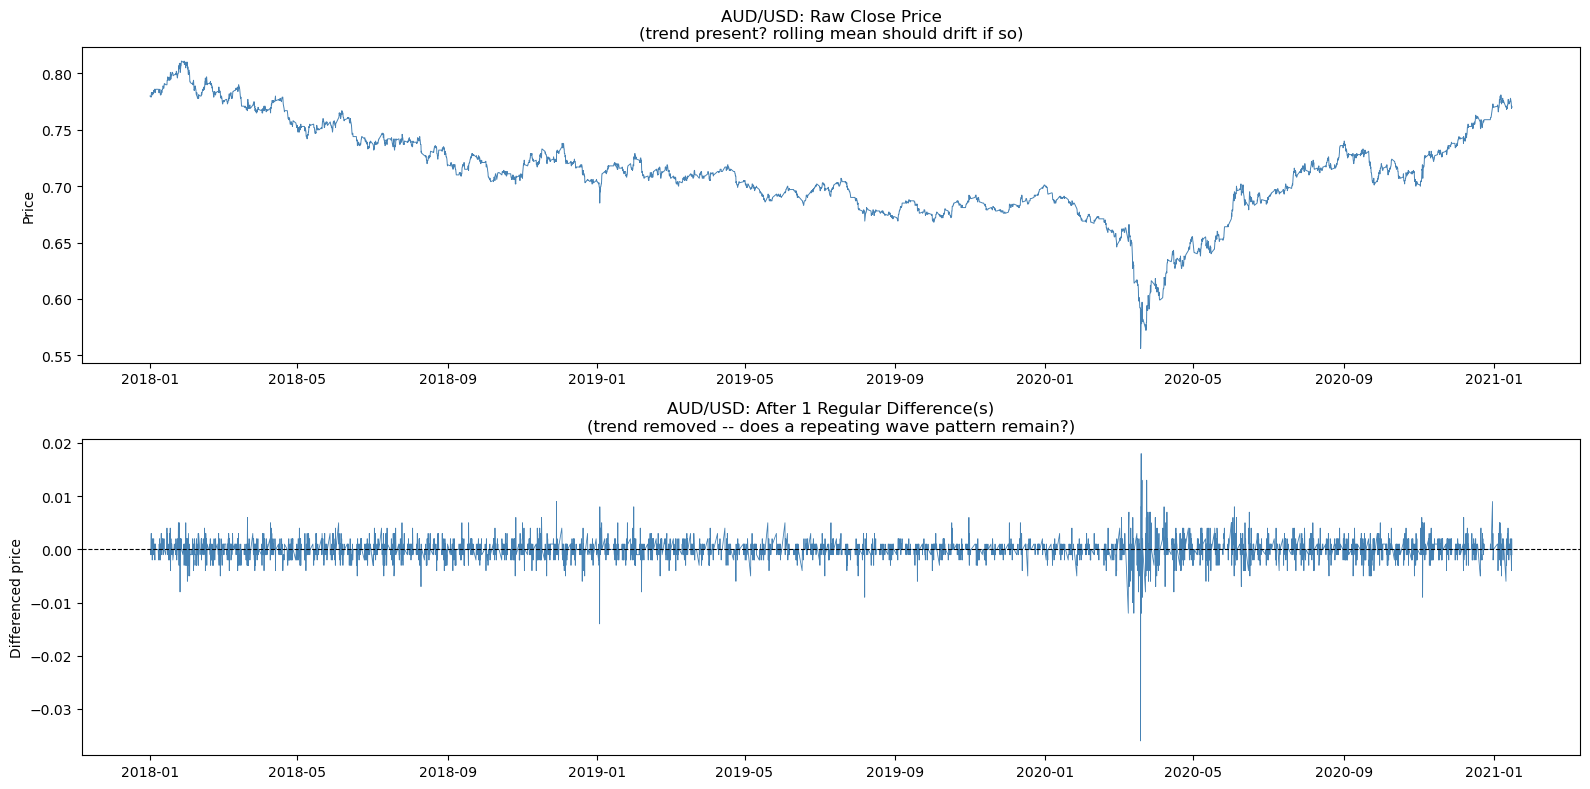

AUD/USD: ADF p-value after 1 difference(s) = 0.000000   --> stationary


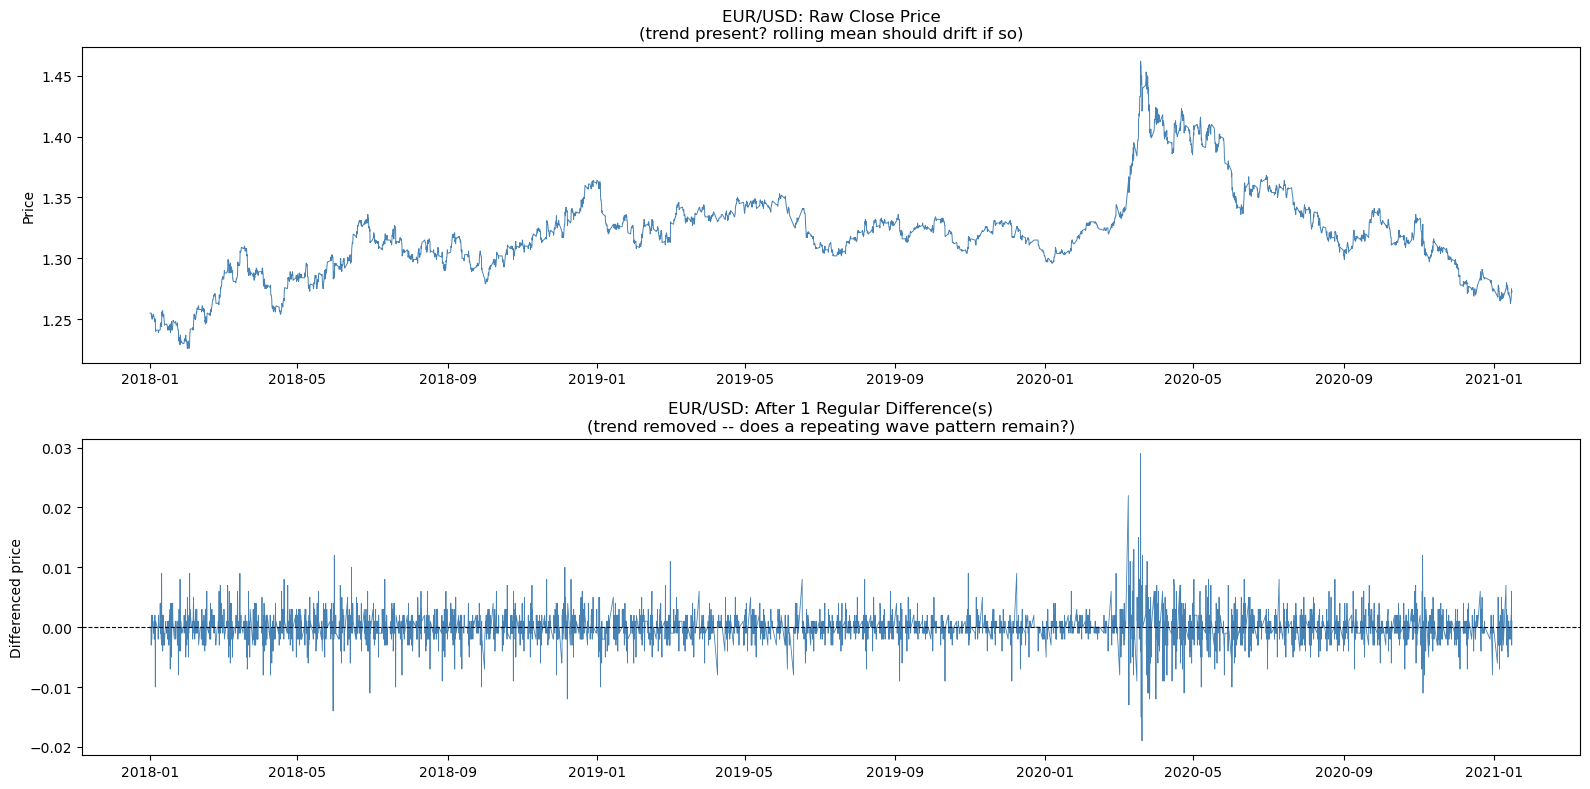

EUR/USD: ADF p-value after 1 difference(s) = 0.000000   --> stationary


In [58]:
# On 4-hour bars, what does each seasonal period mean?
# m=6  --> 6 bars x 4h = 24h  --> 1 trading day
# m=30 --> 30 bars x 4h = 120h --> 1 trading week (5 days)
SEASONAL_CANDIDATES = {
    6:  "1 trading day  (6 x 4h)",
    30: "1 trading week (30 x 4h)"
}

def step1_remove_trend(series, pair_name, d=1):
    """
    Replicates the QuantInsti approach: apply d regular differences
    to remove trend, then plot side by side -- raw vs differenced.
    
    Question being asked: after removing the trend, does a repeating
    pattern remain in the differenced series? That is the seasonal signal.
    """
    differenced = series.copy()
    for _ in range(d):
        differenced = differenced.diff().dropna()

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

    axes[0].plot(series.index, series, color="steelblue", linewidth=0.7)
    axes[0].set_title(f"{pair_name}: Raw Close Price\n"
                      f"(trend present? rolling mean should drift if so)")
    axes[0].set_ylabel("Price")

    axes[1].plot(differenced.index, differenced, color="steelblue", linewidth=0.6)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title(f"{pair_name}: After {d} Regular Difference(s)\n"
                      f"(trend removed -- does a repeating wave pattern remain?)")
    axes[1].set_ylabel("Differenced price")

    plt.tight_layout()
    plt.show()

    # Quick ADF confirmation that differencing achieved stationarity
    adf_p = adfuller(differenced, autolag="AIC")[1]
    print(f"{pair_name}: ADF p-value after {d} difference(s) = {adf_p:.6f} "
          f"  --> {'stationary' if adf_p < 0.05 else 'still non-stationary'}")

    return differenced

diff_aud = step1_remove_trend(df_aud["close"], "AUD/USD", d=d_aud)
diff_eur = step1_remove_trend(df_eur["close"], "EUR/USD", d=d_eur)

#### Check for Seasonal Pattern in ACF at Candidate Lags

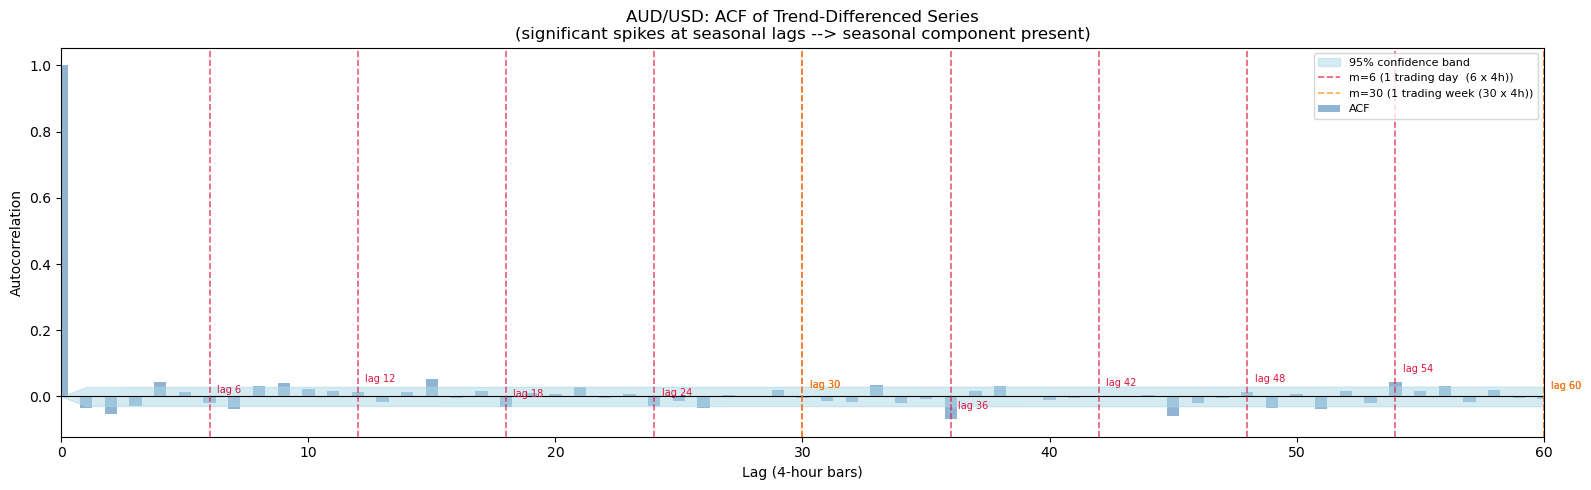


AUD/USD: Seasonal candidate assessment
m      Meaning                        ACF at m     Significant?    ACF at 2m    Pattern?
------------------------------------------------------------------------------------------
6      1 trading day  (6 x 4h)        -0.0198      no              0.0148       no
30     1 trading week (30 x 4h)       -0.0057      no              -0.0077      no


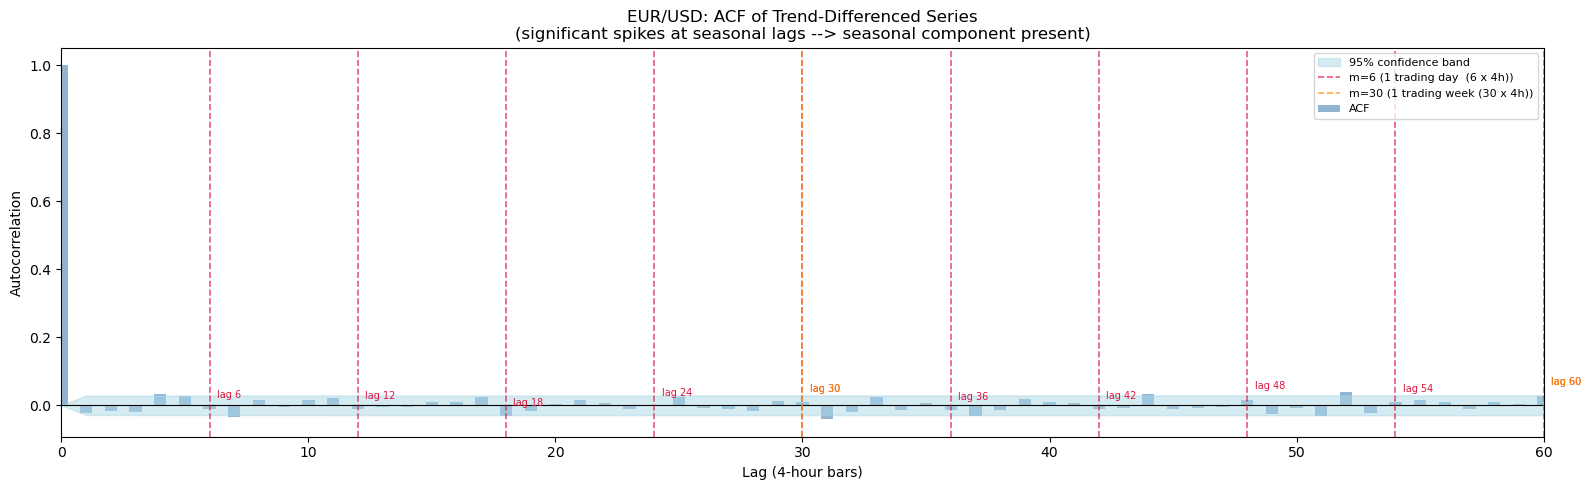


EUR/USD: Seasonal candidate assessment
m      Meaning                        ACF at m     Significant?    ACF at 2m    Pattern?
------------------------------------------------------------------------------------------
6      1 trading day  (6 x 4h)        -0.0098      no              -0.0118      no
30     1 trading week (30 x 4h)       0.0097       no              0.0286       no


In [59]:
def step2_check_seasonal_acf(differenced, pair_name, seasonal_candidates, lags=60):
    """
    After trend removal, plot the ACF out to enough lags to cover
    the seasonal candidates. Following the document:
    
    Significant spikes at multiples of m indicate seasonal AR (P)
    A single significant spike at lag m indicates seasonal MA (Q=1)
    
    On 4h FX bars:
        m=6  --> spike at lags 6, 12, 18 ... suggests daily seasonality
        m=30 --> spike at lags 30, 60 ...    suggests weekly seasonality
    """
    acf_vals, confint = acf(differenced.dropna(), nlags=lags, alpha=0.05, fft=True)
    ci_width = confint[:, 1] - acf_vals  # upper CI margin

    fig, ax = plt.subplots(figsize=(16, 5))

    # Plot ACF bars
    ax.bar(range(len(acf_vals)), acf_vals, color="steelblue",
           alpha=0.6, width=0.5, label="ACF")
    ax.fill_between(range(len(acf_vals)),
                    -ci_width, ci_width,
                    color="lightblue", alpha=0.5, label="95% confidence band")
    ax.axhline(0, color="black", linewidth=0.8)

    # Mark seasonal candidate lags
    colors = ["crimson", "darkorange"]
    for (m, meaning), color in zip(seasonal_candidates.items(), colors):
        multiples = [m * k for k in range(1, lags // m + 1) if m * k <= lags]
        for lag in multiples:
            ax.axvline(lag, color=color, linewidth=1.2,
                       linestyle="--", alpha=0.7,
                       label=f"m={m} ({meaning})" if lag == multiples[0] else "")
            ax.annotate(f"lag {lag}", xy=(lag, acf_vals[lag]),
                        xytext=(lag + 0.3, acf_vals[lag] + 0.03),
                        fontsize=7, color=color)

    ax.set_xlabel("Lag (4-hour bars)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title(f"{pair_name}: ACF of Trend-Differenced Series\n"
                 f"(significant spikes at seasonal lags --> seasonal component present)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(0, lags)

    plt.tight_layout()
    plt.show()

    # Print verdict at each candidate lag
    print(f"\n{pair_name}: Seasonal candidate assessment")
    print(f"{'m':<6} {'Meaning':<30} {'ACF at m':<12} {'Significant?':<15} {'ACF at 2m':<12} {'Pattern?'}")
    print("-" * 90)

    seasonal_verdict = {}
    for m, meaning in seasonal_candidates.items():
        if m < len(acf_vals):
            val_m   = acf_vals[m]
            val_2m  = acf_vals[2*m] if 2*m < len(acf_vals) else np.nan
            sig     = abs(val_m) > ci_width[m]
            pattern = abs(val_m) > ci_width[m] and abs(val_2m) > ci_width[2*m] \
                      if not np.isnan(val_2m) else sig
            seasonal_verdict[m] = {"sig": sig, "pattern": pattern,
                                    "acf_m": val_m, "acf_2m": val_2m}
            print(f"{m:<6} {meaning:<30} {val_m:<12.4f} {'YES ***' if sig else 'no':<15} "
                  f"{val_2m:<12.4f} {'YES -- AR seasonal' if pattern else 'no'}")

    return seasonal_verdict

verdict_aud = step2_check_seasonal_acf(diff_aud, "AUD/USD", SEASONAL_CANDIDATES)
verdict_eur = step2_check_seasonal_acf(diff_eur, "EUR/USD", SEASONAL_CANDIDATES)

#### Step 3: Apply Seasonal Difference and Test

In [60]:
def step3_seasonal_difference(differenced, pair_name, m):
    """
    Apply the seasonal difference: y'_t = y_t - y_{t-m}
    This is exactly the formula from the QuantInsti document.
    
    If the result is now stationary (ADF rejects), D=1 is confirmed.
    Plot before vs after to verify visually -- the repeating wave
    pattern should disappear after seasonal differencing.
    """
    seasonal_diff = differenced - differenced.shift(m)
    seasonal_diff = seasonal_diff.dropna()

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    axes[0].plot(differenced.index, differenced,
                 color="steelblue", linewidth=0.6)
    axes[0].set_title(f"{pair_name}: After Regular Differencing Only\n"
                      f"(seasonal wave pattern still visible?)")
    axes[0].axhline(0, color="black", linewidth=0.7, linestyle="--")

    axes[1].plot(seasonal_diff.index, seasonal_diff,
                 color="steelblue", linewidth=0.6)
    axes[1].axhline(0, color="black", linewidth=0.7, linestyle="--")
    axes[1].set_title(f"{pair_name}: After Regular + Seasonal Difference (m={m})\n"
                      f"y'_t = y_t - y_{{t-{m}}}  "
                      f"(repeating pattern should now be gone)")

    plt.tight_layout()
    plt.show()

    # ADF on the fully differenced series
    adf_p = adfuller(seasonal_diff, autolag="AIC")[1]
    print(f"{pair_name} m={m}: ADF p-value after seasonal diff = {adf_p:.6f} "
          f"--> {'stationary, D=1 confirmed' if adf_p < 0.05 else 'still non-stationary'}")

    return seasonal_diff


# Only apply for m values where a pattern was detected
fully_stationary = {}

for pair_name, differenced, verdict in [
    ("AUD/USD", diff_aud, verdict_aud),
    ("EUR/USD", diff_eur, verdict_eur)
]:
    for m, result in verdict.items():
        if result["pattern"]:
            print(f"\n{pair_name}: applying seasonal difference at m={m}")
            sd = step3_seasonal_difference(differenced, pair_name, m)
            fully_stationary[(pair_name, m)] = sd
        else:
            print(f"\n{pair_name} m={m}: no repeating pattern detected, "
                  f"seasonal differencing not required")


AUD/USD m=6: no repeating pattern detected, seasonal differencing not required

AUD/USD m=30: no repeating pattern detected, seasonal differencing not required

EUR/USD m=6: no repeating pattern detected, seasonal differencing not required

EUR/USD m=30: no repeating pattern detected, seasonal differencing not required


#### AIC/BIC Grid Search

In [61]:
def grid_search_arima(series, d, pair_name, p_range=range(0, 5), q_range=range(0, 5)):
    """
    Fit ARIMA(p, d, q) for all combinations in p_range x q_range.
    Select best model by AIC and BIC separately, then compare.
    A good model scores well on both -- if they disagree, prefer BIC
    (it penalises complexity more heavily, important for forecasting).
    """
    print(f"\n{pair_name}: ARIMA grid search (d={d})")
    print(f"Testing p in {list(p_range)}, q in {list(q_range)}")
    print("Fitting models...\n")

    results = []
    total   = len(p_range) * len(q_range)
    count   = 0

    for p, q in itertools.product(p_range, q_range):
        count += 1
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(series.dropna(), order=(p, d, q))
            fit   = model.fit(method_kwargs={"warn_convergence": False})
            results.append({
                "p": p, "d": d, "q": q,
                "AIC": round(fit.aic, 2),
                "BIC": round(fit.bic, 2),
                "converged": True
            })
            print(f"  [{count:>3}/{total}] ARIMA({p},{d},{q})  AIC={fit.aic:.2f}  BIC={fit.bic:.2f}")
        except Exception as e:
            print(f"  [{count:>3}/{total}] ARIMA({p},{d},{q})  FAILED: {str(e)[:40]}")

    df_results = pd.DataFrame(results).sort_values("AIC")

    print(f"\n--- Top 5 by AIC ---")
    print(df_results.head(5).to_string(index=False))

    print(f"\n--- Top 5 by BIC ---")
    print(df_results.sort_values("BIC").head(5).to_string(index=False))

    best_aic = df_results.iloc[0]
    best_bic = df_results.sort_values("BIC").iloc[0]

    print(f"\n  Best by AIC: ARIMA({int(best_aic.p)},{d},{int(best_aic.q)})  AIC={best_aic.AIC}")
    print(f"  Best by BIC: ARIMA({int(best_bic.p)},{d},{int(best_bic.q)})  BIC={best_bic.BIC}")

    if (best_aic.p == best_bic.p) and (best_aic.q == best_bic.q):
        print(f"\n  AIC and BIC agree. Recommended model: ARIMA({int(best_aic.p)},{d},{int(best_aic.q)})")
    else:
        print(f"\n  AIC and BIC disagree. Defaulting to BIC choice for better generalisability.")
        print(f"  Recommended model: ARIMA({int(best_bic.p)},{d},{int(best_bic.q)})")

    return df_results

results_aud = grid_search_arima(df_aud["close"], d=d_aud, pair_name="AUD/USD")
results_eur = grid_search_arima(df_eur["close"], d=d_eur, pair_name="EUR/USD")


AUD/USD: ARIMA grid search (d=1)
Testing p in [0, 1, 2, 3, 4], q in [0, 1, 2, 3, 4]
Fitting models...

  [  2/25] ARIMA(0,1,1)  AIC=-45690.56  BIC=-45677.66
  [  3/25] ARIMA(0,1,2)  AIC=-45701.50  BIC=-45682.14
  [  4/25] ARIMA(0,1,3)  AIC=-45702.56  BIC=-45676.74
  [  5/25] ARIMA(0,1,4)  AIC=-45707.96  BIC=-45675.69
  [  6/25] ARIMA(1,1,0)  AIC=-45689.92  BIC=-45677.01
  [  7/25] ARIMA(1,1,1)  AIC=-45668.21  BIC=-45648.85
  [  8/25] ARIMA(1,1,2)  AIC=-45700.56  BIC=-45674.75
  [  9/25] ARIMA(1,1,3)  AIC=-45701.04  BIC=-45668.78
  [ 10/25] ARIMA(1,1,4)  AIC=-45705.77  BIC=-45667.05
  [ 11/25] ARIMA(2,1,0)  AIC=-45701.51  BIC=-45682.15
  [ 12/25] ARIMA(2,1,1)  AIC=-45693.47  BIC=-45667.66
  [ 13/25] ARIMA(2,1,2)  AIC=-45708.99  BIC=-45676.73
  [ 14/25] ARIMA(2,1,3)  AIC=-45710.90  BIC=-45672.18
  [ 15/25] ARIMA(2,1,4)  AIC=-45711.47  BIC=-45666.29
  [ 16/25] ARIMA(3,1,0)  AIC=-45704.61  BIC=-45678.80
  [ 17/25] ARIMA(3,1,1)  AIC=-45702.36  BIC=-45670.10
  [ 18/25] ARIMA(3,1,2)  AIC=-45

####  SARIMA Grid Search (only runs if seasonality detected)

In [62]:
def grid_search_sarima(series, d, pair_name, seasonal_period,
                       p_range=range(0, 3), q_range=range(0, 3),
                       P_range=range(0, 2), Q_range=range(0, 2)):
    """
    Fit SARIMA(p,d,q)(P,D,Q,m) where m = seasonal_period.
    D is fixed at 1 (one seasonal difference).
    Only runs if check_seasonality found significant seasonal lags.
    """
    print(f"\n{pair_name}: SARIMA grid search (d={d}, m={seasonal_period})")
    results = []

    combos = list(itertools.product(p_range, q_range, P_range, Q_range))
    print(f"Testing {len(combos)} combinations...\n")

    for p, q, P, Q in combos:
        if p == 0 and q == 0 and P == 0 and Q == 0:
            continue
        try:
            model = SARIMAX(series.dropna(),
                            order=(p, d, q),
                            seasonal_order=(P, 1, Q, seasonal_period),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            fit = model.fit(disp=False)
            results.append({
                "p": p, "d": d, "q": q, "P": P, "Q": Q,
                "m": seasonal_period,
                "AIC": round(fit.aic, 2),
                "BIC": round(fit.bic, 2)
            })
        except Exception:
            pass

    df_results = pd.DataFrame(results).sort_values("AIC")
    print(f"--- Top 5 by AIC ---")
    print(df_results.head(5).to_string(index=False))
    print(f"\n--- Top 5 by BIC ---")
    print(df_results.sort_values("BIC").head(5).to_string(index=False))

    return df_results

# Only run SARIMA search if seasonality was detected
# m=6 corresponds to ~1 trading day on 4h bars
if seasonal_aud:
    sarima_results_aud = grid_search_sarima(df_aud["close"], d=d_aud,
                                             pair_name="AUD/USD", seasonal_period=6)
if seasonal_eur:
    sarima_results_eur = grid_search_sarima(df_eur["close"], d=d_eur,
                                             pair_name="EUR/USD", seasonal_period=6)

#### Plot AIC/BIC Heatmap

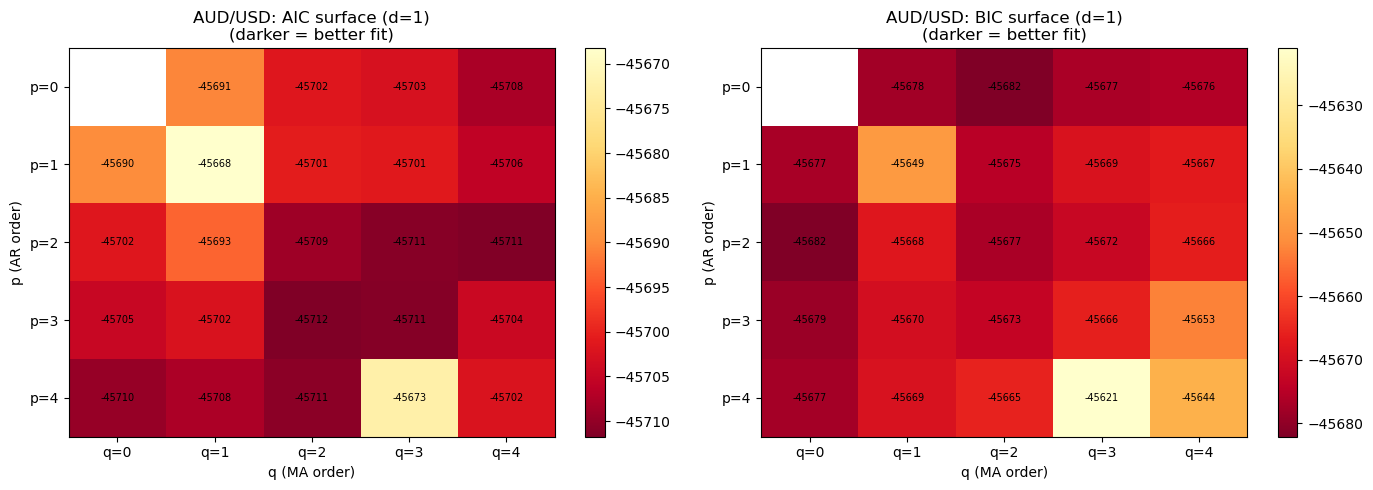

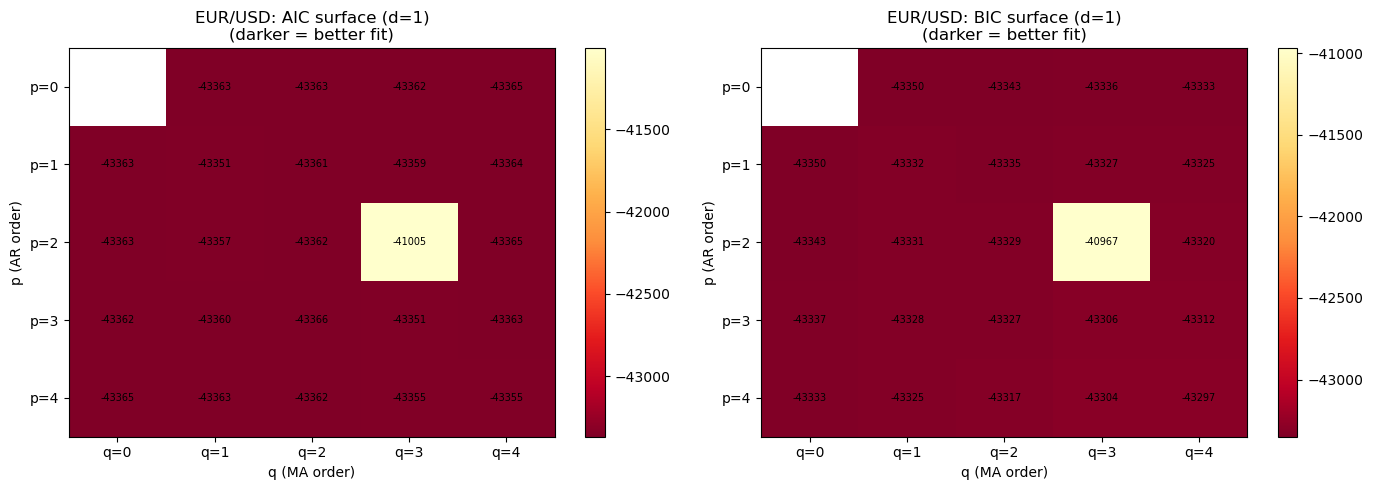

In [63]:
def plot_aic_bic_heatmap(df_results, pair_name, d):
    """
    Visualise the AIC and BIC surfaces across (p, q) combinations.
    The best-fitting cell appears darkest -- makes it easy to see
    whether there is a clear winner or a flat region of near-equal models.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric in zip(axes, ["AIC", "BIC"]):
        pivot = df_results.pivot(index="p", columns="q", values=metric)
        im = ax.imshow(pivot, cmap="YlOrRd_r", aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels([f"q={c}" for c in pivot.columns])
        ax.set_yticklabels([f"p={i}" for i in pivot.index])
        ax.set_xlabel("q (MA order)")
        ax.set_ylabel("p (AR order)")
        ax.set_title(f"{pair_name}: {metric} surface (d={d})\n(darker = better fit)")

        # Annotate cells
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.iloc[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                            fontsize=7, color="black")
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

plot_aic_bic_heatmap(results_aud, "AUD/USD", d=d_aud)
plot_aic_bic_heatmap(results_eur, "EUR/USD", d=d_eur)

#### Final Model Selection Summary

In [64]:
def summarise_model_selection(pair_name, d, results_df, seasonal=False,
                               sarima_results=None, seasonal_period=None):
    """
    Print a clean decision summary to carry forward into notebook 03.
    """
    best_bic = results_df.sort_values("BIC").iloc[0]
    p, q     = int(best_bic.p), int(best_bic.q)

    print(f"  MODEL SELECTION SUMMARY: {pair_name}")
    print(f"{'-'*55}")
    print(f"  Integration order d      : {d}")
    print(f"  Seasonality detected     : {seasonal}")
    print(f"  Best ARIMA (BIC)         : ARIMA({p},{d},{q})  BIC={best_bic.BIC}")

    if seasonal and sarima_results is not None and len(sarima_results) > 0:
        best_sarima = sarima_results.sort_values("BIC").iloc[0]
        sp, sq, sP, sQ = int(best_sarima.p), int(best_sarima.q), \
                          int(best_sarima.P), int(best_sarima.Q)
        print(f"  Best SARIMA (BIC)        : SARIMA({sp},{d},{sq})"
              f"({sP},1,{sQ},{seasonal_period})  BIC={best_sarima.BIC}")
        if best_sarima.BIC < best_bic.BIC:
            print(f"\n  RECOMMENDATION: SARIMA({sp},{d},{sq})({sP},1,{sQ},{seasonal_period})")
            print(f"  Seasonal model wins by BIC delta = {best_bic.BIC - best_sarima.BIC:.2f}")
        else:
            print(f"\n  RECOMMENDATION: ARIMA({p},{d},{q})")
            print(f"  Non-seasonal model wins despite seasonal lags -- "
                  f"seasonal component adds complexity without payoff.")
    else:
        print(f"\n  RECOMMENDATION: ARIMA({p},{d},{q})")

    print(f"{'='*55}\n")
    return {"model_type": "SARIMA" if seasonal else "ARIMA",
            "order": (p, d, q), "pair": pair_name}

selection_aud = summarise_model_selection(
    "AUD/USD", d_aud, results_aud,
    seasonal=seasonal_aud,
    sarima_results=sarima_results_aud if seasonal_aud else None,
    seasonal_period=6
)

selection_eur = summarise_model_selection(
    "EUR/USD", d_eur, results_eur,
    seasonal=seasonal_eur,
    sarima_results=sarima_results_eur if seasonal_eur else None,
    seasonal_period=6
)

# Save selections for notebook 03
import json
with open(os.path.join(data_path, "model_selections.json"), "w") as f:
    json.dump({"AUD/USD": selection_aud, "EUR/USD": selection_eur}, f, indent=2)

print("Model selections saved to model_selections.json")

  MODEL SELECTION SUMMARY: AUD/USD
-------------------------------------------------------
  Integration order d      : 1
  Seasonality detected     : False
  Best ARIMA (BIC)         : ARIMA(2,1,0)  BIC=-45682.15

  RECOMMENDATION: ARIMA(2,1,0)

  MODEL SELECTION SUMMARY: EUR/USD
-------------------------------------------------------
  Integration order d      : 1
  Seasonality detected     : False
  Best ARIMA (BIC)         : ARIMA(0,1,1)  BIC=-43350.37

  RECOMMENDATION: ARIMA(0,1,1)

Model selections saved to model_selections.json
